# Residual Stream Dynamics: 

**Eric T. Wolf, Ph.D.**<br>
*University of Colorado*<br> 
*Laboratory for Atmospheric and Space Physics*<br>

## Motivation

Motivated by my background in numerical modeling of physical systems (i.e. climate, planetary systems, radiative transfer, atmospheric dynamics, etc), I am interested in the studying the evolution of residual and logi streams of large language models through the lens of dynamical systems and physics-based intuitions.  Perhaps the most obvious parallel is in the concept of entropy. In statistical mechanics, entropy is the measure of disorder or randomness in a thermodynamic system.  In 1948, Claude Shannon, in his seminal paper "A Mathematical Theory of Communication" (10.1002/j.1538-7305.1948.tb01338.x), realized that the thermodynamic definition of entropy could be used to quantify the amount of information in a communication.  Later, Alred Renyi generallized the definition of entropy to a family of metrics known as Rényi entropies, parameterized by $\alpha$, 

$$H_\alpha(X) = \frac{1}{1-\alpha} \log \sum_{i=1}^n p_i^\alpha$$

where $\alpha = 1$ corresponds to Shannon entropy.  In the context of LLMs, entropy provides insight into the geometrical representation of the information that flows through the network layers.  In this ongoing project, I have developed a simple framework for analyzing the Renyi entropy and logit lens entropy across network layers and model architectures for small-sized open-weight LLMs GPT-2 (small–XL) and Pythia (160M–6.9B).

## Corpus

Our initial experiments have been conducted with small corpus, consisting of 50 prompt pairs (25 base / 25 contrast) drawn from `corpus/base_vs_contrast_n50.json`. Each pair shares a category (e.g. *pattern*, *factual*, *syntactic*) with the base prompt having a clear, semantically grounded continuation and the contrast prompt injecting ambiguity into the sequence.  Future work will expand the size and diversity of the corpus while centering around contrasting pairs or sequences including: concrete vs abstract, formal vs informal, factual vs counter factual, and progressive noise injection on both syntatic and semantic content.  Ideally, I would like to extend entropy and framing to logic and reasoning level prompt sequences, however compute limitations restrict my exploration to simple models and straight forward prompts.

## Workflow

Bulk results and figures were first produced running workflows scripts in `workflows/`, referencing computational algorithms in `entrop_compute.py` and `ablation_compute.py`, and bulk multipanel plotting routines in `entropy_plots.py` and `ablation_plots.py`.  The following scripts were run for each model architecture:

```bash
python workflows/ablation_analysis.py --corpus base_vs_contrast_n50.json --model $model --ev-thresholds 0.1 0.25 0.50 0.75 0.90 0.95 0.99 --stage2 --save-data 
python workflows/wu_subspace_analysis.py --corpus base_vs_contrast_n50.json --model $model --also-residual --also-logit-lens  --save-data
python workflows/entropy_analsys.py --corpus base_vs_contrast_n50.json --model $model --logit-lens --save-data
```

This juypter notebook reproduces the key results and figures in a more organized manner, and will serve as a basis for futher development of the project's science directions.

## Four Claims Demonstrated Here

1. **Anti-correlation of Entropy and Logit Lens Certainty** — coherent (base) prompts show *higher* residual stream entropy yet *more certain* logit lens predictions than ambiguous (contrast) prompts.
    
2. **Cross-architecture replication** — the anti-correlation holds across GPT-2 (small–XL) and Pythia (160M–6.9B).
3. **Fragility at 99% explained variance** — retaining 99% of W_U explained variance, approximately 20% of prompts change their top-1 predicted token.
4. **Differential sensitivity** — coherent prompts are more sensitive than ambiguous prompts to removal of low-singular-value W_U components, confirming a causal role for the "low-influence" residual stream complement.


## Setup

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image

# load utilities for processing saved .npz data blocks from computational workflows
from npz_utils import (
    load_entropy_npz,
    get_final_token_profiles,
    load_ablation_npz,
    get_ablation_records,
    build_intervention_heatmap,
)
# load plotting utilities for producing figures from the saved .npz data blocks
from post_process_plots import (
    load_all_models,
    plot_entropy_profiles,
    plot_paired_difference,
    plot_paired_difference_grid,
    compute_scaling_summary,
    plot_scaling_summary,
    plot_ablation_entropy_change,
    plot_top1_vs_k,
    plot_intervention_heatmap,
)

DATA_DIR    = Path('../data')
FIGURES_DIR = Path('../figures/notebooks')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CORPUS_TAG  = 'base_vs_contrast_n50'
MODEL       = 'gpt2-small'   # single-model demonstration

MODELS = [    # full suite of models
    'gpt2-small', 'gpt2-medium', 'gpt2-large', 'gpt2-xl',
    'pythia-160m', 'pythia-1b', 'pythia-2.8b', 'pythia-6.9b',
]

%matplotlib inline


---

## 1. Claim 1 — Anti-Correlation Between Residual Stream Entropy and Logit Lens Entropy (GPT-2 Small only)

> *"Coherent prompts show higher residual stream entropy yet more certain logit lens predictions."*

We begin with GPT-2 small (124M parameters, 12 layers) to establish the core finding.

Two panels show the entropy ± 95% confidence interval for an mean  across all 25 base and 25 contrast prompts as a function of **fractional layer depth** (0 = embedding, 1 = final layer):

- **Left**: residual stream entropy (energy normalization) — geometric spread of activations in d_model space.
- **Right**: logit lens entropy — uncertainty of the next-token prediction when unembedding at each intermediate layer.
- **Caveat**: applying R @ W_U at each layer comes with the uncertainty that the unembedding matrix is optimized for the final layer only. However, this is the standard approach for computing logit lens entropy.

The anti-correlation is the central empirical result: base prompts are geometrically *more spread* (left panel) yet produce *more certain* predictions (right panel).


In [2]:
data_sm = load_entropy_npz(DATA_DIR / f'entropy_records_{MODEL}_{CORPUS_TAG}.npz')

base_resid,     _, _, _ = get_final_token_profiles(data_sm, norm_key='energy',     role='base')
contrast_resid, _, _, _ = get_final_token_profiles(data_sm, norm_key='energy',     role='contrast')
base_logit,     _, _, _ = get_final_token_profiles(data_sm, norm_key='logit_lens', role='base')
contrast_logit, _, _, _ = get_final_token_profiles(data_sm, norm_key='logit_lens', role='contrast')


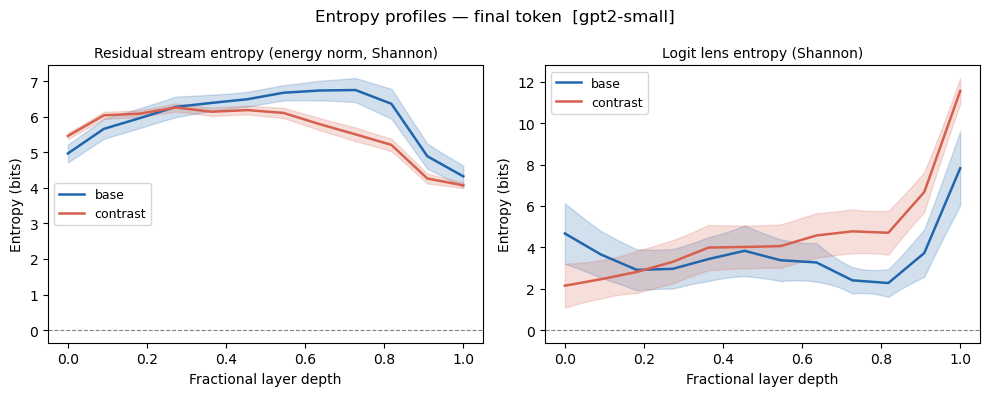

In [3]:
fig, axes = plot_entropy_profiles(
    base_resid, contrast_resid,
    base_logit, contrast_logit,
    model_name=MODEL,
    save_path=FIGURES_DIR / f'entropy_profiles_{MODEL}.png',
)
plt.show()


### Paired difference

The signed difference (base minus contrast) makes the anti-correlation explicit.

- **Positive** = base > contrast
- **Negative** = base < contrast

The sign *reversal* between residual stream (positive, peaking mid-network) and logit lens (negative, growing toward the final layer) — across the same set of prompts — is the central empirical signature of Claim 1.


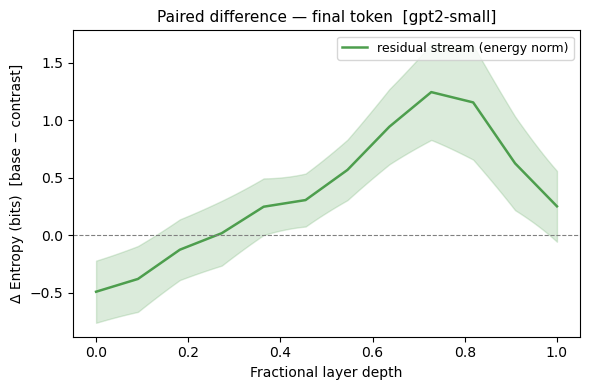

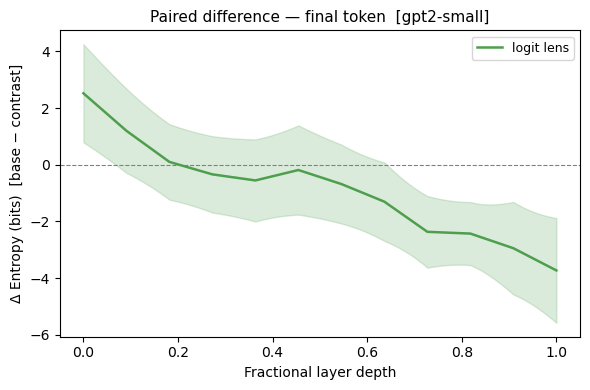

In [4]:
fig, ax = plot_paired_difference(
    base_resid, contrast_resid,
    model_name=MODEL, label='residual stream (energy norm)',
    save_path=FIGURES_DIR / f'paired_diff_resid_{MODEL}.png',
)
plt.show()

fig, ax = plot_paired_difference(
    base_logit, contrast_logit,
    model_name=MODEL, label='logit lens',
    save_path=FIGURES_DIR / f'paired_diff_logit_{MODEL}.png',
)
plt.show()


---

## 2. Claim 2 — Cross-Architecture Replication

> *"Holds across all tested architectures and scales."*

The anti-correlation between residual stream entropy and logit lens entropy replicates across GPT-2 (small, medium, large, XL) and Pythia (160M, 1B, 2.8B, 6.9B). Profiles are plotted on shared **fractional-depth axes**, enabling direct visual comparison across models with different layer counts.  Also plotted is the paired-differences between the two entropy measures along with the 95% confidence interval.  Note that the y-axis range is fixed across all models to facilitate comparison.


In [5]:
model_data = load_all_models(MODELS, DATA_DIR, CORPUS_TAG)


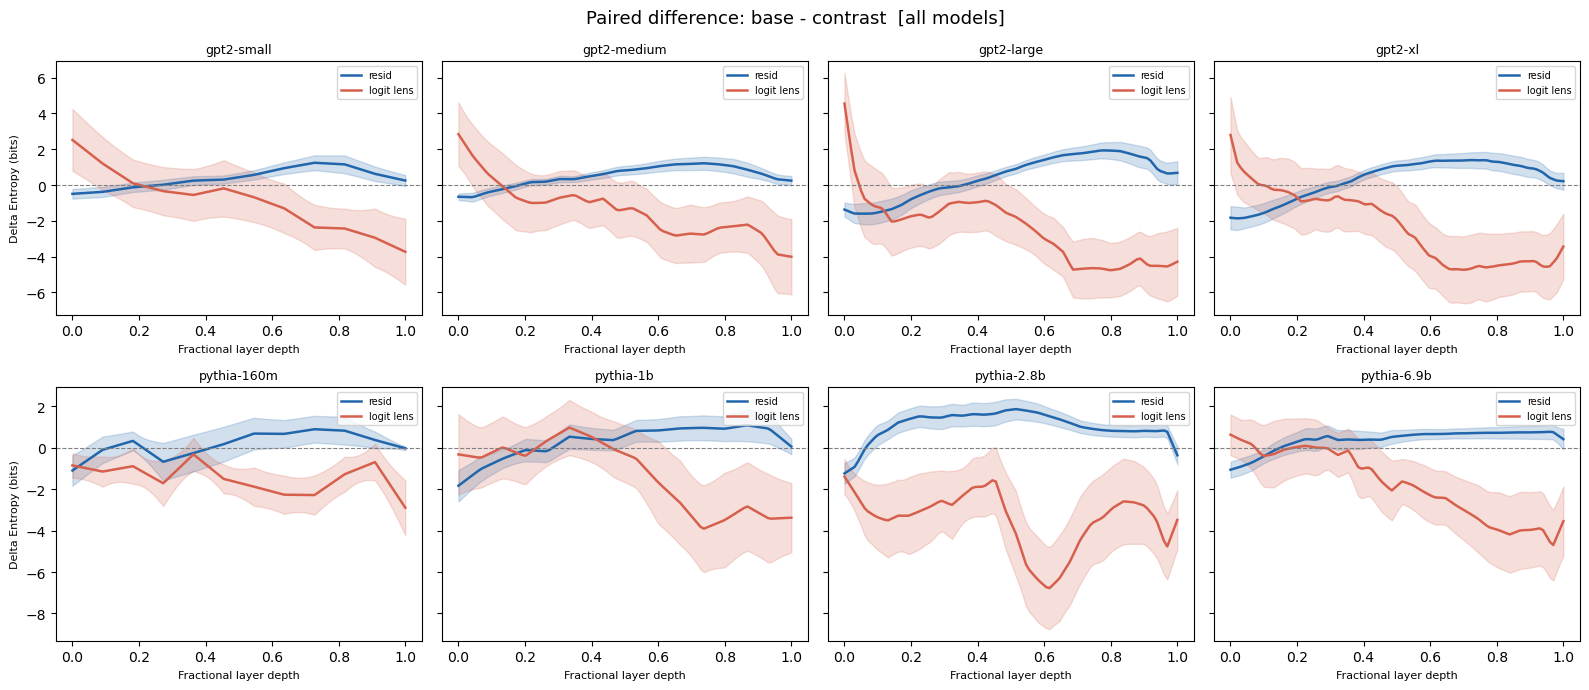

In [6]:
fig, axes = plot_paired_difference_grid(
    model_data,
    save_path=FIGURES_DIR / 'paired_difference_all_models.png',
)
plt.show()


---

## 3. Interpretations:

We interpret the anti-correlation between residual stream entropy and logit lens entropy for base(coherent) vs contrast(ambigous) prompts as follows:

The base prompts build a richer conceptual space in the residual stream, occuppying a larger representational geometry.  When projected into the logit space via R @W_U, the broad distribution of the residual stream is collapsed into a narrower distribution of logits.  Ambiguous prompts are not able to build a rich contextually space owing to the ambiguity of the initial prompt, but when projected onto the logit space this results in a higher entropy, more uncertainty.  This opposing behavior of residual stream versus logit stream entropy for coherent versus ambiguos prompts leads us to ask, if there exists an anti-correlation in the geometric representation (via entropy) of the residual stream to logit-stream trends, how much of and what parts of the residual stream is doing the real work in predicting the next token.  Since R and WU are full-rank, a clean decomposition of parallel and orthogonal components is not possible. Thus I performed a singular value decomposition of W_U and performed post-hoc and intervention ablation experiments for the R @ W_U decoding of the residual stream into token predictions.


W_U Subspace Structure — Why Does Spread Produce Certainty?

The unembedding matrix **W_U** (shape [d_model, vocab_size]) maps residual stream vectors to logits. Its singular value spectrum determines which residual stream directions carry the most predictive influence.

A low-rank W_U would show a sharp elbow: a few singular vectors explain most variance. The spectrum below is instead remarkably **flat**: approximately 600 of 768 dimensions are needed to explain 92% of variance in GPT-2 small.

**Implication**: there is no natural low-rank prediction subspace. The r∥ / r⊥ decomposition is better understood as a **high-influence vs. low-influence spectrum** rather than a clean partition — W_U is full rank and no directions are truly orthogonal to prediction. This motivates asking whether the "low-influence" complement carries structured information that downstream computations consume.

*(Figures pre-computed from `workflows/wu_subspace_analysis.py`. To regenerate: `python workflows/wu_subspace_analysis.py --model $MODEL --corpus base_vs_contrast_n50.json`)*



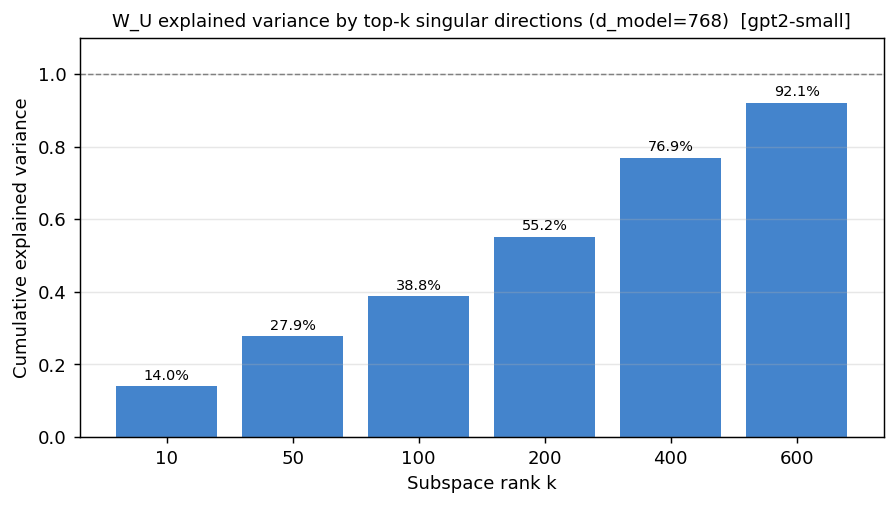

In [7]:
# Pre-computed singular value spectrum of W_U for GPT-2 small
Image('../figures/notebooks/wu_explained_variance_gpt2-small.png')


---

## 4. Claim 3 — Top-1 Token Fragility Across All Models

> *"Retaining 99% of W_U explained variance, ~20% of prompts change top-1 predicted token."*

**Stage 1 — Post-hoc ablation**: the residual stream is projected onto the top-k right singular vectors of W_U at readout only (the forward pass is not modified). We examine two metrics across all models in the suite:

- **Top-1 preservation rate** = fraction of prompts where the argmax predicted token is unchanged after ablation, plotted against *relative subspace rank* k / d_model so that models with different hidden dimensions are directly comparable.

Showing all models strengthens Claim 3: the top-1 fragility near full rank is not a quirk of GPT-2 small but a consistent property across architectures and scales.

Base prompts have higher residual stream entropy than contrast prompts.  The diffuse geometry is not noise, removing even a small fraction of the lower SVD orders can change the top-1 toek predictions strongly.

There is geometric spread is carrying signal relateive to token selection, not just energy.

### 4b. Top-1 token preservation vs. relative subspace rank k / d_model

Each curve shows the fraction of prompts (averaged over base and contrast) whose top predicted token is preserved when the residual stream is projected onto the top-k singular directions of W_U, plotted against *relative rank* k / d_model.

Using relative rank places all models on a common x-axis despite their different hidden dimensions — analogous to normalizing pressure levels across model grids of different vertical resolution. A sharp drop near k / d_model = 1 (i.e. near full rank) is the signature of Claim 3: token identity requires nearly the full residual stream, not just the high-singular-value subspace.


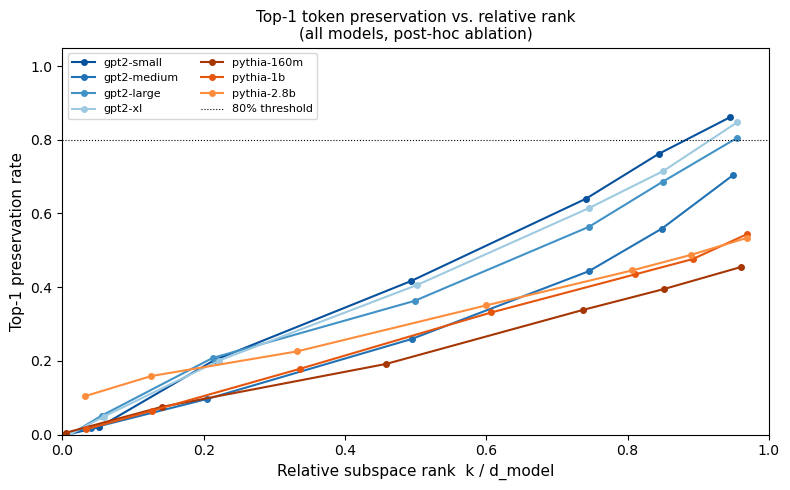

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

# Color families: blues for GPT-2, oranges for Pythia
colors = {
    'gpt2-small':  '#08519c', 'gpt2-medium': '#2171b5',
    'gpt2-large':  '#4292c6', 'gpt2-xl':     '#9ecae1',
    'pythia-160m': '#a63603', 'pythia-1b':   '#e6550d',
    'pythia-2.8b': '#fd8d3c', 'pythia-6.9b': '#fdae6b',
}

for m in MODELS:
    if m not in abl_all:
        continue

    abl = abl_all[m]
    d   = D_MODEL[m]
    ks_avail = sorted([int(k) for k in np.unique(abl['ks'])])

    preservation_rates = []
    rel_ranks = []
    for k in ks_avail:
        _, _, base_top1,     _, _ = get_ablation_records(abl, role='base',     ablation_type='posthoc', k=k)
        _, _, contrast_top1, _, _ = get_ablation_records(abl, role='contrast', ablation_type='posthoc', k=k)
        # pool base and contrast for an overall preservation rate
        combined = np.concatenate([base_top1, contrast_top1])
        preservation_rates.append(float(np.mean(combined)))
        rel_ranks.append(k / d)

    ax.plot(rel_ranks, preservation_rates,
            marker='o', markersize=4,
            color=colors.get(m, 'gray'),
            label=m)

ax.axhline(0.80, color='black', linewidth=0.8, linestyle=':', label='80% threshold')
ax.set_xlabel('Relative subspace rank  k / d_model', fontsize=11)
ax.set_ylabel('Top-1 preservation rate', fontsize=11)
ax.set_title('Top-1 token preservation vs. relative rank\n(all models, post-hoc ablation)', fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'ablation_top1_vs_relrank_all_models.png', dpi=150, bbox_inches='tight')
plt.show()


---

## 5. Claim 4 — Differential Sensitivity: Base Prompts More Affected

> *"Coherent prompts more sensitive to removal of low-singular-value components."*

Post-hoc ablation (Section 4) modifies only the readout. **Stage 2 — forward-pass intervention** directly zeros out the r⊥ component at a chosen layer *before* subsequent layers process it. This is the causal test.

If r⊥ is noise, downstream layers are unaffected. If it carries structured information that later computations consume, predictions degrade — and base prompts should degrade *more*, since Claim 1 showed they build more total residual stream structure during the forward pass.

The heatmaps below show the **base minus contrast difference** in each metric across:
- **x-axis**: intervention layer (which layer's r⊥ is zeroed)
- **y-axis**: subspace rank k (how much of W_U subspace is retained at readout)

**Red** = base prompts more affected than contrast; **blue** = contrast more affected. Claim 4 predicts predominantly red across the heatmaps.


In [11]:
k_values          = sorted([int(k) for k in np.unique(abl['ks']) if k > 0])
intervention_lyrs = sorted([int(l) for l in np.unique(abl['intervention_lyrs']) if l >= 0])

print('k values for intervention:    ', k_values)
print('intervention layers:          ', intervention_lyrs)


k values for intervention:     [83, 322, 850, 1536, 2065, 2277, 2480]
intervention layers:           [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]


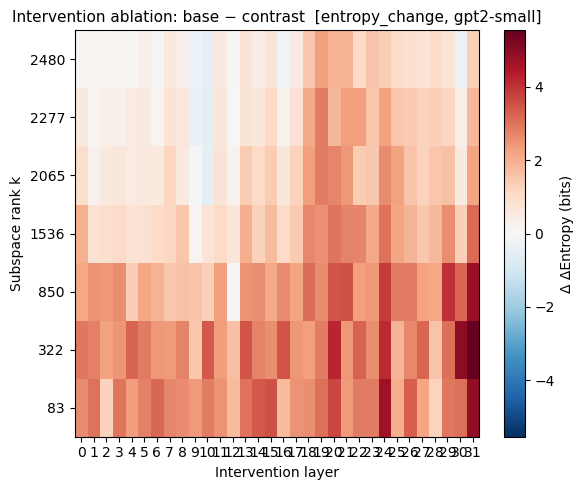

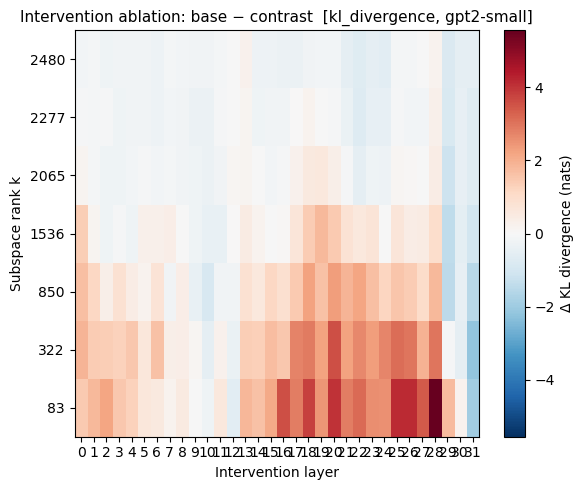

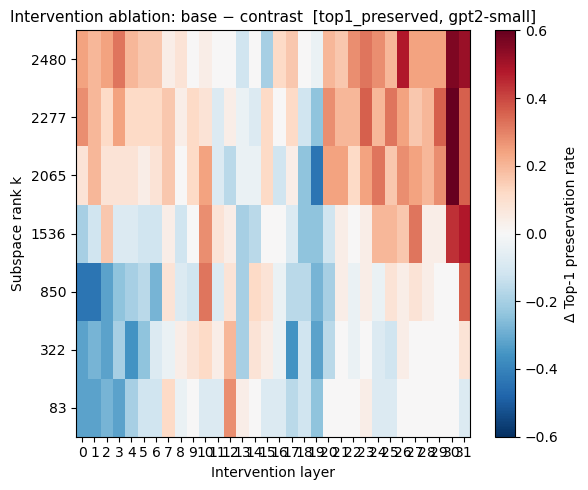

In [12]:
for metric in ['entropy_change', 'kl_divergence', 'top1_preserved']:
    base_mat     = build_intervention_heatmap(abl, metric=metric, role='base',
                                              k_values=k_values, intervention_lyrs=intervention_lyrs)
    contrast_mat = build_intervention_heatmap(abl, metric=metric, role='contrast',
                                              k_values=k_values, intervention_lyrs=intervention_lyrs)
    diff_mat = base_mat - contrast_mat

    fig, ax = plot_intervention_heatmap(
        diff_mat, k_values, intervention_lyrs,
        model_name=MODEL, metric=metric,
        save_path=FIGURES_DIR / f'intervention_heatmap_{metric}_{MODEL}.png',
    )
    plt.show()


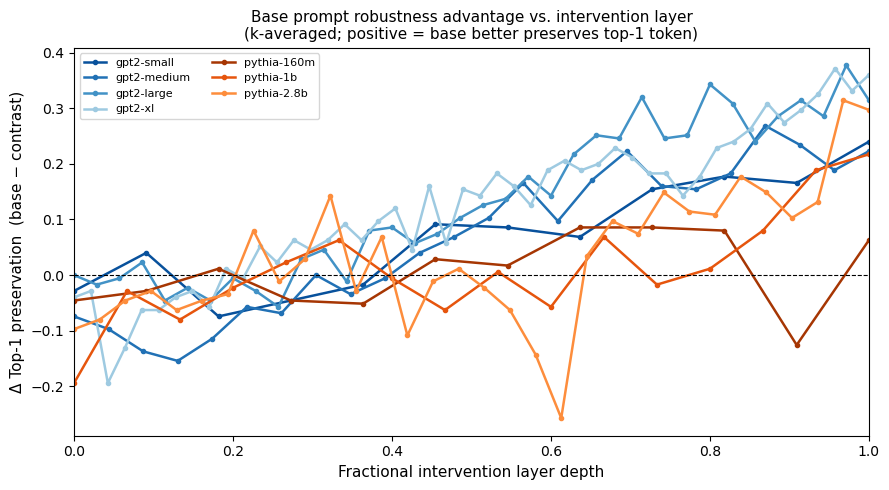

In [17]:
# Collapse intervention heatmaps to layer profiles
# For each model: average Base−Contrast top-1 preservation difference across all k values,
# leaving a single curve as a function of intervention layer (fractional depth).
# Non-uniform k-grids across models are handled naturally — we average whatever k values exist.

fig, ax = plt.subplots(figsize=(9, 5))

colors = {
    'gpt2-small':  '#08519c', 'gpt2-medium': '#2171b5',
    'gpt2-large':  '#4292c6', 'gpt2-xl':     '#9ecae1',
    'pythia-160m': '#a63603', 'pythia-1b':   '#e6550d',
    'pythia-2.8b': '#fd8d3c', 'pythia-6.9b': '#fdae6b',
}

for m in MODELS:
    if m not in abl_all:
        continue

    abl  = abl_all[m]
    k_values_m = sorted([int(k) for k in np.unique(abl['ks']) if k > 0])
    int_lyrs_m = sorted([int(l) for l in np.unique(abl['intervention_lyrs']) if l >= 0])
    n_layers   = max(int_lyrs_m) + 1  # for fractional depth normalisation

    # Build difference matrix: shape [n_k, n_intervention_layers]
    base_mat     = build_intervention_heatmap(abl, metric='top1_preserved', role='base',
                                              k_values=k_values_m,
                                              intervention_lyrs=int_lyrs_m)
    contrast_mat = build_intervention_heatmap(abl, metric='top1_preserved', role='contrast',
                                              k_values=k_values_m,
                                              intervention_lyrs=int_lyrs_m)
    diff_mat = base_mat - contrast_mat   # shape [n_k, n_int_lyrs], positive = base more robust

    # Collapse across k: mean over all available subspace ranks
    layer_profile = diff_mat.mean(axis=0)   # shape [n_int_lyrs]

    # Smooth the layer profile
    window = 3
    smoothed = np.convolve(layer_profile, np.ones(window)/window, mode='same')


    frac_depth = np.array(int_lyrs_m) / (n_layers - 1)
    ax.plot(frac_depth, layer_profile,
            marker='o', markersize=3, linewidth=1.8,
            color=colors.get(m, 'gray'), label=m)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Fractional intervention layer depth', fontsize=11)
ax.set_ylabel('Δ Top-1 preservation  (base − contrast)', fontsize=11)
ax.set_title('Base prompt robustness advantage vs. intervention layer\n'
             '(k-averaged; positive = base better preserves top-1 token)', fontsize=11)
ax.set_xlim(0, 1)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'intervention_top1_layer_profile_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 6. Synthesis and Interpretation

### The Build-Then-Cash-Out Dynamic

The two ablation stages together support a *build-then-cash-out* interpretation of how coherent prompts produce confident predictions despite high geometric entropy:

1. **Early-to-middle layers build** structured content in the low-influence r⊥ complement — more so for semantically rich (base) prompts than ambiguous (contrast) prompts.
2. **Later layers cash out** this structure, converting it into focused logit distributions.
3. The **final residual stream** therefore shows high geometric entropy (the accumulated structure) alongside low logit entropy (the sharpened prediction).

The layer 2–4 spatial specificity visible in the intervention heatmaps is mechanistically informative: it localizes *where* in the network the r⊥ structure is both written and consumed.

### Summary of Evidence

| Claim | Result |
|-------|--------|
| 1. Anti-correlation | Base > contrast in residual entropy; base < contrast in logit entropy; sign reversal confirmed across all layers |
| 2. Cross-architecture | Replicates across GPT-2 (small–XL) and Pythia (160M–6.9B) |
| 3. Top-1 fragility | ~20% of prompts flip top-1 token at 99% W_U explained variance |
| 4. Differential sensitivity | Base prompts more sensitive to r⊥ removal (Stage 2 intervention heatmaps) |

### Open Questions

- What does r⊥ specifically encode? Candidates include syntactic binding, world-knowledge scaffolding, and long-range context.
- Does the build-then-cash-out dynamic strengthen with model scale? Multi-model ablation results are deferred to future work.
- The per-direction logit influence spectrum c_k = σ_k (r · v_k) would provide a direct quantitative test — see `FutureWork.md`.


### heat maps of the top1 preservations for all models show
- high k, middle to late layes, base better preserves than contrast.
-higher k as a generality, the more subspace retained the more top1 preserved.
- ablation late in the neural network is more damaging to top1 preservation for contrast plots, base prompts already have encoded responses in more dominate modes
- small ablations (high-k) in the first few layers are recoverable
- middle layer representations are mixed

Base prompts have already resolved their prediction into a stable, high-confidence attractor by the final layer. Even when you intervene and remove the r⊥ component mid-network, the forward pass has enough redundancy built into the high-influence subspace to recover the correct token. Contrast prompts, being genuinely ambiguous, sit closer to a decision boundary — so the same intervention is more likely to flip them.

At high subspace rank, base prompts are more robust to forward-pass intervention than contrast prompts — consistent with their predictions sitting further from the token-selection decision boundary."


4:08 PMThis is exactly the right question to be asking, and it sharpens the whole story considerably.
The apparent paradox:

Base prompts have higher residual stream entropy → more energy spread across more dimensions → r⊥ carries more energy for base prompts
Yet removing r⊥ hurts base prompts less in top-1 preservation

How can removing more energy cause less damage?
The resolution:
Residual stream entropy is a geometric measure — it tells you how spread the activation vector is across d_model dimensions. But W_U doesn't weight all dimensions equally. Its singular value spectrum determines which directions matter for prediction.
The key insight is that base prompts don't just have more total spread — from §2 (the W_U subspace structure), we know the spectrum is flat, meaning prediction signal is distributed across many dimensions. But base prompts apparently load their predictively relevant energy more heavily into the high-singular-value directions — the dominant modes. The extra spread that gives them higher residual stream entropy is concentrated in r⊥, the low-influence directions.
So when you ablate r⊥:

You remove a lot of geometric energy from base prompts (they had more there)
But that energy wasn't doing much predictive work — the dominant modes already had the answer locked in
The prediction is robust because the signal that matters was never in r⊥ to begin with

For contrast prompts the situation is different:

Less total residual stream entropy, but their predictive signal is less concentrated in dominant modes
They sit near a decision boundary, so even a small perturbation from r⊥ removal can flip the argmax
Their ambiguity means no single attractor is strongly encoded in the high-k subspace

So the residual stream entropy and the robustness result are not in tension — they're two sides of the same coin:

Base prompts are geometrically spread because they've encoded rich structured content across many dimensions including r⊥ — but their prediction is robust because the dominant modes already carry a decisive signal. The high residual stream entropy reflects the richness of the representation, not uncertainty about the answer. Contrast prompts are geometrically tighter but predictively fragile because their signal is diffuse across the W_U spectrum without a clear dominant-mode attractor.

This is actually a refinement of the build-then-cash-out framing. The "cashing out" isn't just happening in the final layer — it's happening progressively into the high-singular-value directions of W_U, so that by the time you reach the final layer the prediction is overdetermined in those directions even as r⊥ continues accumulating structured content.
That's a genuinely interesting mechanistic picture, and it ties all four claims together into one coherent argument.